In [1]:
%config Completer.use_jedi = False

# Function test

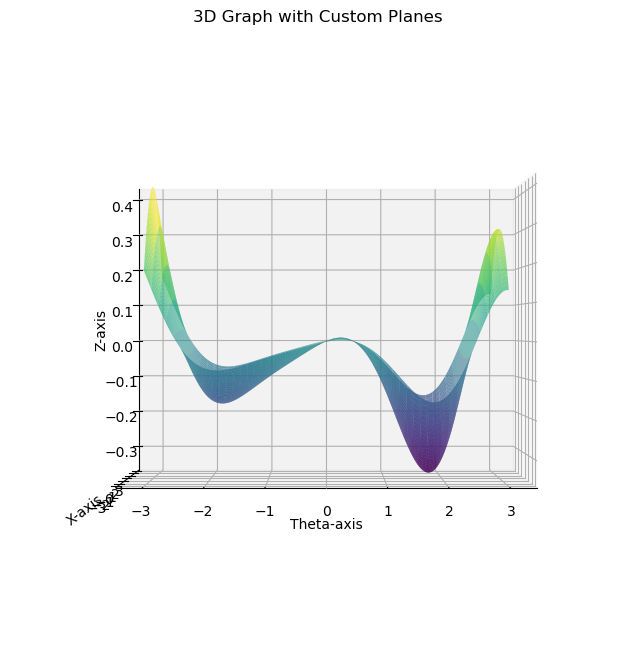

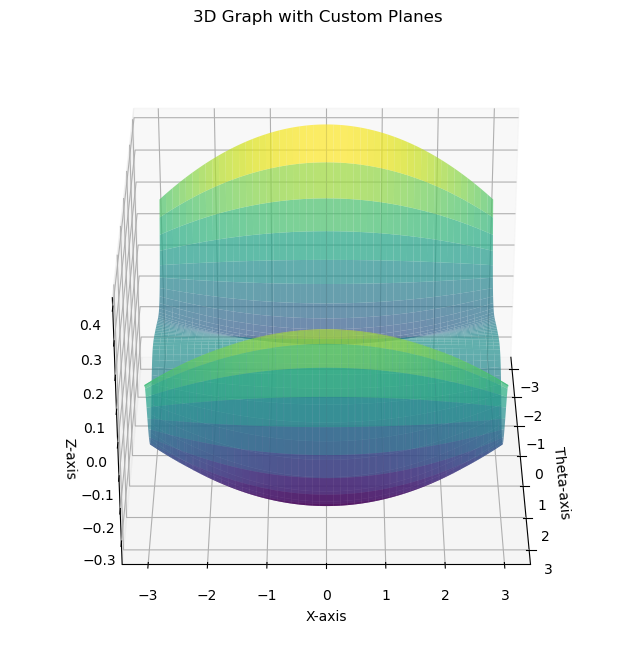

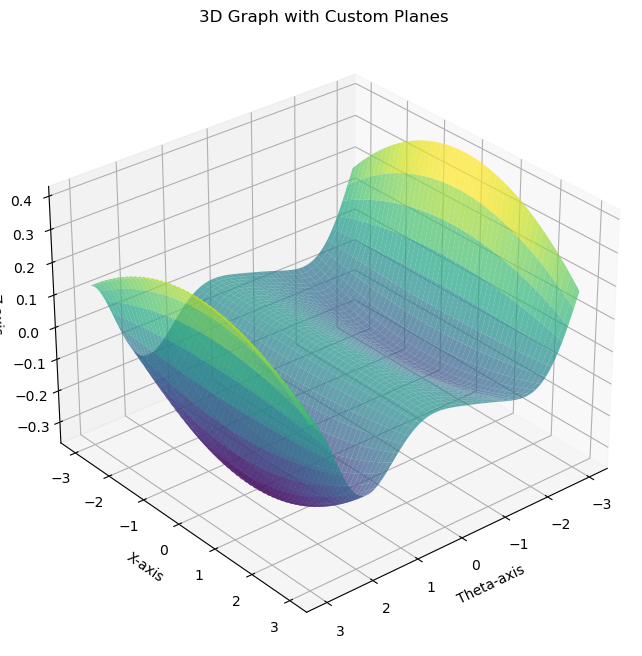

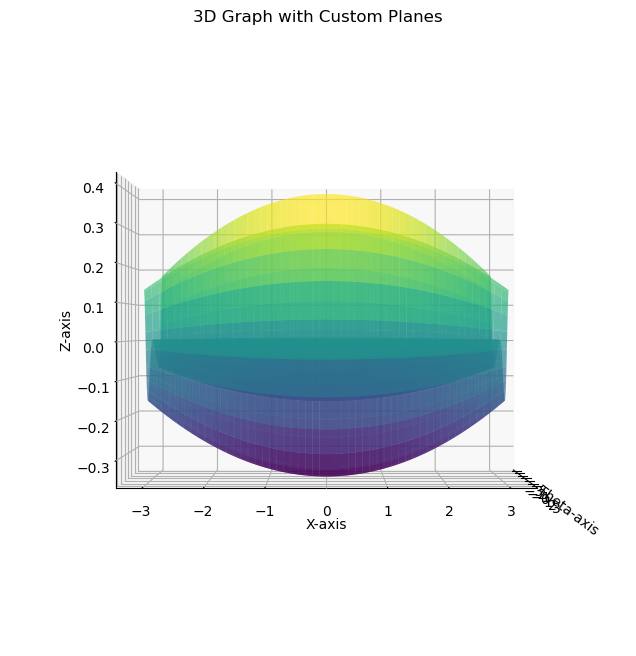

In [485]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_custom_3d_graph(elev, azim):
    # Define the range for x and y
    xx = np.linspace(-3, 3, 400)
    yy = np.linspace(-3, 3, 400)
    theta, x = np.meshgrid(xx, yy)

    # Define the equations for each plane
    # 1. X-Y plane: y = (x-a)(x-b)(x-c) + d
    #Z = (Y+4)*(Y-4)*((X - a) * (X - b) * (X - c)/100 + d)
    Z = (x+4)*(x-4)*(theta*-4*np.cos(theta*4/(2*np.pi))*np.cos((theta+3.8)*(theta-2)/(2*np.pi)))*np.cos(4*(theta+2)/(2*np.pi))/(100)
    
    
    # Create the figure
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot X-Y plane
    ax.plot_surface(theta,x, Z, alpha=0.7, cmap='viridis', edgecolor='none', label='theta-x plane')
    ax.view_init(elev = elev, azim=azim)

    # Set labels and title
    ax.set_xlabel('Theta-axis')
    ax.set_ylabel('X-axis')
    ax.set_zlabel('Z-axis')
    ax.set_title('3D Graph with Custom Planes')

    # Show the plot
    plt.show()

# Example usage with sample constants
plot_custom_3d_graph(0, -90)
plot_custom_3d_graph(30, 0)
plot_custom_3d_graph(30, 50)
plot_custom_3d_graph(0, 0)

# 자료
- GD -> SGD -> MiniBatch-GD -> with Momentum -> NAG -> Adagrad -> AdaDelta -> RMSProp -> ADAM

In [ ]:
import time
import numpy as np

# Define the function
def loss_function(theta, x):
    return (x+4)*(x-4)*(theta*-4*np.cos(theta*4/(2*np.pi))*np.cos((theta+3.8)*(theta-2)/(2*np.pi)))*np.cos(4*(theta+2)/(2*np.pi))/20
    return (x+4)*(x-4)*(theta*-4*np.cos(theta*4/(2*np.pi))*np.cos((theta+3.8)*(theta-2)/(2*np.pi)))/100
    return (x+4)*(x-4)*(theta*-4*np.cos(theta*4/(2*np.pi))*np.cos((theta-2)/(2*np.pi)))/100

def gradient_function(theta, x):
    return (x - 4)*(x + 4)*(theta*(2*theta + 1.8)*np.sin((theta - 2)*(theta + 3.8)/(2*np.pi))*np.cos(2*theta/np.pi)*np.cos(2*(theta + 2)/np.pi) + 4*theta*np.sin(2*theta/np.pi)*np.cos(2*(theta + 2)/np.pi)*np.cos((theta - 2)*(theta + 3.8)/(2*np.pi)) + 4*theta*np.sin(2*(theta + 2)/np.pi)*np.cos(2*theta/np.pi)*np.cos((theta - 2)*(theta + 3.8)/(2*np.pi)) - 2*np.pi*np.cos(2*theta/np.pi)*np.cos(2*(theta + 2)/np.pi)*np.cos((theta - 2)*(theta + 3.8)/(2*np.pi)))/(10*np.pi)
    return (x - 4)*(x + 4)*(theta*(2*theta + 1.8)*np.sin((theta - 2)*(theta + 3.8)/(2*np.pi))*np.cos(2*theta/np.pi) + 4*theta*np.sin(2*theta/np.pi)*np.cos((theta - 2)*(theta + 3.8)/(2*np.pi)) - 2*np.pi*np.cos(2*theta/np.pi)*np.cos((theta - 2)*(theta + 3.8)/(2*np.pi)))/(50*np.pi)
    return (((x-4)*(x+4)*((theta*(2*theta + 1.8)*np.sin((theta - 2)*(theta + 3.8)/(2*np.pi))*np.cos(2*theta/np.pi) + 4*theta*np.sin(2*theta/np.pi)*np.cos((theta - 2)*(theta + 3.8)/(2*np.pi)) - 2*np.pi*np.cos(2*theta/np.pi)*np.cos((theta - 2)*(theta + 3.8)/(2*np.pi)))))/100) / (50 * np.pi)
    return (x+4)*(x-4)*(-4*np.cos(theta*2/np.pi)*np.cos((theta-2)/(2*np.pi))+theta*4*np.sin(2*theta/np.pi)*np.cos((theta-2)/(2*np.pi)))/100
    return (x**2 - 16)*(-4*np.cos(1.5*theta/np.pi)+6*theta*np.sin(1.5*theta/np.pi)/np.pi)/100 
    return 0.01*(x+3)*(x-4)*((theta*2)*(theta-2)+(theta-1)*(theta-2) + (theta-1)*(theta+2))
    return 4*theta*(theta**2 + x**2 -3) + np.cos(theta+x) - np.sin(2*theta-x)

def get_x(theta, value, data):
    diff_hist = []
    for x in data:
        diff_hist.append([x, np.sqrt((loss_function(theta, x) - value)**2)])
    return sorted(diff_hist, key=lambda x: x[1])[0][0]
    
def sgd(initial_theta, learning_rate, steps, data):
    start = time.time()
    theta = initial_theta
    history = []
    
    mean_loss = np.mean([loss_function(theta, x) for x in data])
    x = get_x(theta, mean_loss, data)
    history.append((theta, x, mean_loss, 0))
    for step in range(steps):
        x = np.random.choice(data)  # 랜덤 샘플 선택
        grad = gradient_function(theta,x)  # 선택된 샘플로 기울기 계산
        theta -= learning_rate * grad 

        mean_loss = np.mean([loss_function(theta, x) for x in data])
        x = get_x(theta, mean_loss, data)
        history.append((theta, x, mean_loss, step+1))

    end = time.time()
    return history, start, end

def sgd_with_momentum(initial_theta, learning_rate, steps, data, momentum_beta =0.9):
    start = time.time()
    theta = initial_theta
    vel = 0
    history = []
    
    mean_loss = np.mean([loss_function(theta, x) for x in data])
    x = get_x(theta, mean_loss, data)
    history.append((theta, x, mean_loss, 0))
    for step in range(steps):
        x = np.random.choice(data)  # 랜덤 샘플 선택
        #x=0
        grad = gradient_function(theta,x)  # 선택된 샘플로 기울기 계산
        vel = momentum_beta * vel - learning_rate * grad 
        theta += vel
        if theta > 4:
            break

        mean_loss = np.mean([loss_function(theta, x) for x in data])
        x = get_x(theta, mean_loss, data)
        history.append((theta, x, mean_loss, step+1))

    end = time.time()
    return history, start, end
    
# NAG 구현
def nag(initial_theta, learning_rate, steps, data, momentum_beta =0.9):
    start = time.time()
    theta = initial_theta
    vel = 0
    history = []
    
    mean_loss = np.mean([loss_function(theta, x) for x in data])
    x = get_x(theta, mean_loss, data)
    history.append((theta, x, mean_loss, 0))
    for step in range(steps):
        x = np.random.choice(data)  # 랜덤 샘플 선택
        #x = 0
        grad = gradient_function(theta + learning_rate*vel,x)  # 선택된 샘플로 기울기 계산
        vel = momentum_beta * vel - learning_rate * grad 
        theta += vel
        if theta > 4:
            break

        mean_loss = np.mean([loss_function(theta, x) for x in data])
        x = get_x(theta, mean_loss, data)
        history.append((theta, x, mean_loss, step+1))

    end = time.time()
    return history, start, end

def nag2(initial_theta, learning_rate, steps, data, momentum_beta =0.9):
    start = time.time()
    theta = initial_theta
    vel = 0
    history = []
    
    mean_loss = np.mean([loss_function(theta, x) for x in data])
    x = get_x(theta, mean_loss, data)
    history.append((theta, x, mean_loss, 0))
    for step in range(steps):
        x = np.random.choice(data)  # 랜덤 샘플 선택
        #x =0
        grad = gradient_function(theta, x)
        vel = momentum_beta*vel - learning_rate*grad
        vel = momentum_beta*vel - learning_rate*grad
        
        #grad = gradient_function(theta + learning_rate*vel,x)  # 선택된 샘플로 기울기 계산
        theta += vel
        if theta > 4:
            break

        mean_loss = np.mean([loss_function(theta, x) for x in data])
        x = get_x(theta, mean_loss, data)
        history.append((theta, x, mean_loss, step+1))

    end = time.time()
    return history, start, end

def adagrad(initial_theta, learning_rate, steps, data, beta1 =0.9, beta2=0.999):
    epsilon= 1e-8
    start = time.time()
    theta = initial_theta
    history = []
    
    mean_loss = np.mean([loss_function(theta, x) for x in data])
    x = get_x(theta, mean_loss, data)
    history.append((theta, x, mean_loss, 0))
    acc_g = 0
    for step in range(steps):
        x =0
        x = np.random.choice(data)  # 랜덤 샘플 선택
        grad = gradient_function(theta, x)
        acc_g += grad**2
        theta -= learning_rate*grad/np.sqrt(acc_g+ epsilon)
        if theta > 4:
            break

        mean_loss = np.mean([loss_function(theta, x) for x in data])
        x = get_x(theta, mean_loss, data)
        history.append((theta, x, mean_loss, step+1))

    end = time.time()
    return history, start, end

def rmsprop(initial_theta, learning_rate, steps, data,gamma=0.9):
    epsilon= 1e-8
    start = time.time()
    theta = initial_theta
    history = []
    
    mean_loss = np.mean([loss_function(theta, x) for x in data])
    x = get_x(theta, mean_loss, data)
    history.append((theta, x, mean_loss, 0))
    acc_g = 0
    for step in range(steps):
        x =0
        x = np.random.choice(data)  # 랜덤 샘플 선택
        grad = gradient_function(theta, x)
        acc_g = gamma*acc_g + (1-gamma)*(grad**2)

        theta -= learning_rate*grad/np.sqrt(acc_g+ epsilon)
        if theta > 4:
            break

        mean_loss = np.mean([loss_function(theta, x) for x in data])
        x = get_x(theta, mean_loss, data)
        history.append((theta, x, mean_loss, step+1))

    end = time.time()
    return history, start, end

def adadelta_v2(initial_theta, learning_rate, steps, data,gamma=0.5):
    epsilon= 1e-8
    start = time.time()
    theta = initial_theta
    history = []
    
    mean_loss = np.mean([loss_function(theta, x) for x in data])
    x = get_x(theta, mean_loss, data)
    history.append((theta, x, mean_loss, 0))
    acc_g = 0
    acc_theta = epsilon
    for step in range(steps):
        x =0
        x = np.random.choice(data)  # 랜덤 샘플 선택
        grad = gradient_function(theta, x)

        acc_g = gamma*acc_g + (1-gamma)*(grad**2)
        delta_v = -np.sqrt((acc_theta+epsilon)/ (acc_g+epsilon))*grad

        acc_theta = gamma*acc_theta + (1-gamma)*(delta_v**2)
        theta += delta_v
        #print(grad, acc_g, acc_theta,delta_v)
        if theta > 4:
            break

        mean_loss = np.mean([loss_function(theta, x) for x in data])
        x = get_x(theta, mean_loss, data)
        history.append((theta, x, mean_loss, step+1))

    end = time.time()
    return history, start, end

def adam(initial_theta, learning_rate, steps, data, beta1 =0.9, beta2=0.999):
    start = time.time()
    theta = initial_theta
    m = v = 0
    history = []
    
    mean_loss = np.mean([loss_function(theta, x) for x in data])
    x = get_x(theta, mean_loss, data)
    history.append((theta, x, mean_loss, 0))

    for step in range(steps):
        x = np.random.choice(data)  # 랜덤 샘플 선택
        grad = gradient_function(theta, x)  # 선택된 샘플로 기울기 계산

        m = beta1 * m + (1-beta1)*grad
        v = beta2 * v + (1-beta2)*(grad **2)

        m_hat = m / (1-(beta1**(step+1)))
        v_hat = v / (1-(beta2**(step+1)))

        theta -= learning_rate * m_hat / (np.sqrt(v_hat)+1e-8)
        if theta > 4:
            break

        mean_loss = np.mean([loss_function(theta, x) for x in data])
        x = get_x(theta, mean_loss, data)
        history.append((theta, x, mean_loss, step+1))

    end = time.time()
    return history, start, end

def adam_v2(initial_theta, learning_rate, steps, data, beta1 =0.9, beta2=0.999):
    start = time.time()
    theta = initial_theta
    m = v = 0
    history = []
    
    mean_loss = np.mean([loss_function(theta, x) for x in data])
    x = get_x(theta, mean_loss, data)
    history.append((theta, x, mean_loss, 0))

    for step in range(steps):
        x = np.random.choice(data)  # 랜덤 샘플 선택
        grad = gradient_function(theta, x)  # 선택된 샘플로 기울기 계산

        beta_1_power = beta1**(step+1)
        beta_2_power = beta2**(step+1)

        alpha = learning_rate*np.sqrt(1-beta_2_power) / (1-beta_1_power)

        m =  m + (1-beta1)*(grad-m)
        v = v + ((grad**2)-v)*(1-beta2)

        #v_hat = np.max(v_hat, v)
        #v = v_hat
        
        theta -= learning_rate * (m*alpha)/ (np.sqrt(v)+1e-8)
        if theta > 4:
            break

        mean_loss = np.mean([loss_function(theta, x) for x in data])
        x = get_x(theta, mean_loss, data)
        history.append((theta, x, mean_loss, step+1))

    end = time.time()
    return history, start, end

methods = {
    'SGD':{
        'func':sgd,
        'color':'orange',
        'marker':'v',
    },
    'SGD+MOMENTUM':{
        'func': sgd_with_momentum,
        'color':'magenta',
        'marker':'^',
    },
    'NAG':{
        'func': nag,
        'color' :'blue',
        'marker': 'x',
    },
    'NAG2':{
        'func': nag2,
        'color' :'black',
        'marker': '.',
    },
    'ADAGRAD':{
        'func':adagrad,
        'color':'cyan',
        'marker':'.'
        
    },
    'RMSProp':{
        'func':rmsprop,
        'color':'magenta',
        'marker':'^'
    },
    'ADADELTA_V2':{
        'func':adadelta_v2,
        'color':'green',
        'marker':'v'
    },
    'ADAM':{
        'func':adam,
        'color':'cyan',
        'marker':'x'
    },
    'ADAM2':{
        'func':adam_v2,
        'color':'red',
        'marker':'x'
    }
}

# 초기화
start_point = -3
learning_rate = 0.22#0.001#0.22
steps = 100
data = np.linspace(-3,3,400)


# Generate data for the surface
theta = np.linspace(-3, 3, 400)
THETA, X = np.meshgrid(theta, data)
Z = loss_function(THETA, X)


available_method = [m for m in methods if 'func' in methods[m]]
pData = {}
for method in available_method:
    result = methods[method]['func'](start_point, learning_rate, steps, data)
    pData[method] = result

**GD** : 경사하강법을 이용해서 Loss가 최저가되는 지점을 찾자!<br>
**SGD** : 전체 데이터마다 Parameter를 Update하니 너무 오래 걸린다.. 매 포인트마다 Update를 해보자. <br>
**Mini-Batch GD** : SGD로 하니 잡음이 너무 많다. 매 포인트마다가 아니라 일정 포인트 마다 (batch_size) Update해보자. <br>

--> Update하는 주기는 짧아졌는데,아직 최적점으로 수렴하는 속도가 너무 느리다. 
어떻게 빨리 갈 수 있을까? 
1) Gradient가 0이되는 구간에서 멈추면 Saddle Point에서 최저점을 못 찾는다..!
2) learning rate가 크면 수렴 구간에서 진동하고,, 작으면 수렴속도가 너무 느려진다.. 
   그럼 Adaptive하게 Learning Rate를 바꿔보자!

## Momentum
- SGD는 Loss의 기울기 만큼만 이동한다. Gradient에 비례하는 이동거리만 정해짐! --> 기울기가 속도로 작용!
- Update과정에서 이전 속도를 저장해서  Gradient가 0이 되어도 좀 더 이동할 수 있게 하자 --> 기울기가 가속도로 작용!

SGD<br>
$\theta_{t+1} = \theta_t + V_t$<br>
$V_t = -\eta\nabla_\theta J({\theta_t}): Loss의 기울기$<br>


Momentum<br>
$\theta_{t+1} = \theta_t + V_t$<br>
$V_t = -\eta\nabla_\theta J({\theta_t}) - \gamma V_{t-1}$<br>
$\gamma =$ Momentum Constant

SGD: 0.46 Sec
SGD+MOMENTUM: 0.36 Sec


C:\Users\tardis\AppData\Local\Temp\ipykernel_4684\2630421343.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


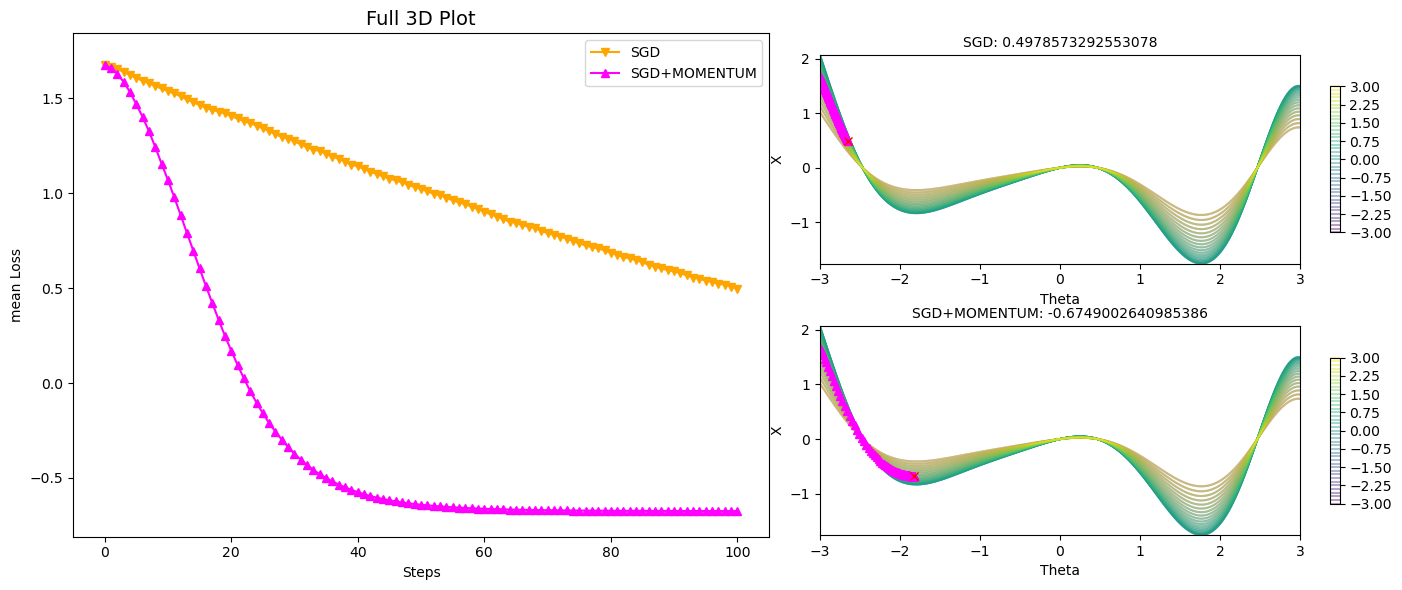

In [609]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create the main GridSpec for 1x2 layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

use_methods = ['SGD','SGD+MOMENTUM']
# First subplot: Full plot
ax_left = fig.add_subplot(gs[0])
max_y = 0
min_y = 0
for method in use_methods:
    values, start, end = pData[method]
    color = methods[method]['color']
    marker = methods[method]['marker']
    max_y = np.max([max_y, values[0][2]])
    min_y = np.min([min_y, np.min(list(zip(*values))[2])])
    print(f'{method}: {np.round(end - start,2)} Sec')
    
    ax_left.plot(*tuple(zip(*values))[-2:][::-1], color=color, marker = marker, label=method)
ax_left.set_title('Full 3D Plot', fontsize=14)
ax_left.set_xlabel('Steps')
ax_left.set_ylabel('mean Loss')
ax_left.set_ylim([min_y - 0.2 * np.abs(min_y), max_y*1.1])
ax_left.legend()

# Add colorbar to the left plot

# Second subplot: 3x1 layout within the right panel
gs_sub = GridSpec(len(use_methods), 1, figure=fig, left=0.55, right=0.95, top=0.9, bottom=0.1, hspace=0.3)
for i, method in enumerate(use_methods):
    ax = fig.add_subplot(gs_sub[i])
    cmap = plt.get_cmap('coolwarm')  # Set the colormap
    surf = ax.contour(THETA, Z,X, levels=50,cmap='viridis', alpha=0.4)
    ax.plot(*tuple(zip(*pData[method][0]))[:3][::2], color=color, marker = marker)
    ax.plot(*pData[method][0][-1][:3][::2], color='red', marker = 'x')
    ax.set_title(f'{method}: {np.min(tuple(zip(*pData[method][0]))[2])}', fontsize=10)

    ax.set_xlabel('Theta')
    ax.set_ylabel('X')

    # Add colorbar to each subplot
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## NAG
Momentum이 추가되니 기울기가 0인 곳에서 멈추지 않고 계속해서 이동한다 ㅎㅎ 

그런데 진동 때문에 수렴하는게 좀 늦네?

보니까 Momentum은 경사면에서는 가속되어서 좋은데 경사 방향이 바뀌는 곳에서 속도를 못 줄이네.. 
다음 위치의 기울기를 반영하면 감속이 해야할 때 미리 줄일 수 있겠다!

- Momentum<br>
$\theta_{t+1} = \theta_t + V_t$<Br>
$V_t = - \eta \nabla_\theta J(\theta_t)-\gamma V_{t-1} $

- NAG (Nesterov Accelerated Gradient)<br>
$\theta_{t+1} = \theta_t+ V_t$<Br>
$ V_t = -\eta \nabla_\theta J(\theta_{pred}) - \gamma V_{t-1} $<br>
$ \theta_{pred} = \theta_{t-1} +  \gamma V_{t-1}$<br>
$ \therefore V_t = -\eta \nabla_\theta J(\theta_{t-1}+\gamma V_{t-1}) - \gamma V_{t-1}$

현재 속도를 이용해 다음 위치를 구하고 다음 위치에서의 기울기로 속도를 업데이트!

하지만 구현상 예상 Theta에서의 기울기를 구하는 것은 비용이 크기 때문에 
간소화된 구현방식을 사용한다. 

- 간소화 식<br>
$\theta_{t+1} = \theta_t+ V_{final}$<Br>
$ V_t = -\eta \nabla_\theta J(\theta_t) - \gamma V_{t-1} $<br>
$ V_{final} = -\eta \nabla_\theta J(\theta_t) - \gamma V_{t} $<br>

... 속도를 두번 업데이트 한다..!
https://github.com/keras-team/keras/blob/4c05e0cd2dfd385fb9db204885ddf51635b9e9b7/keras/src/optimizers/sgd.py#L117

SGD+MOMENTUM: 0.34 Sec
NAG2: 0.37 Sec


C:\Users\tardis\AppData\Local\Temp\ipykernel_4684\1585423484.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


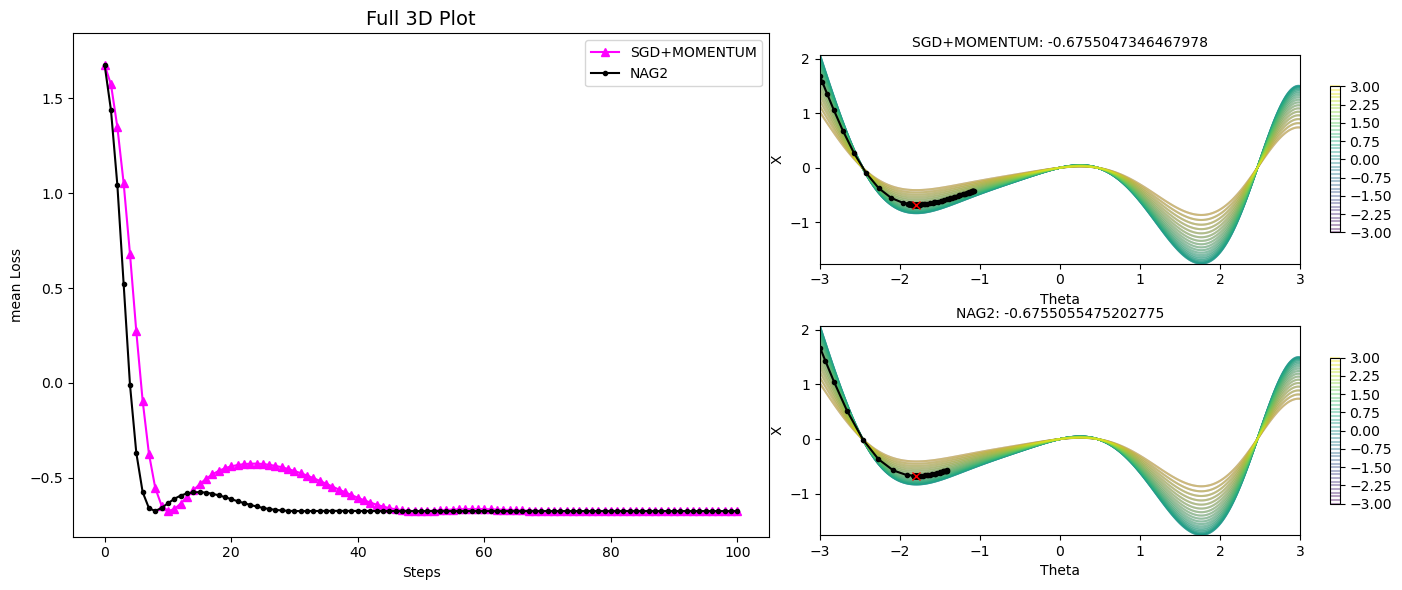

In [583]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create the main GridSpec for 1x2 layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

use_methods = ['SGD+MOMENTUM', 'NAG2']
# First subplot: Full plot
ax_left = fig.add_subplot(gs[0])
max_y = 0
min_y = 0
for method in use_methods:
    values, start, end = pData[method]
    color = methods[method]['color']
    marker = methods[method]['marker']
    max_y = np.max([max_y, values[0][2]])
    min_y = np.min([min_y, np.min(list(zip(*values))[2])])
    print(f'{method}: {np.round(end - start,2)} Sec')
    
    ax_left.plot(*tuple(zip(*values))[-2:][::-1], color=color, marker = marker, label=method)
ax_left.set_title('Full 3D Plot', fontsize=14)
ax_left.set_xlabel('Steps')
ax_left.set_ylabel('mean Loss')
ax_left.set_ylim([min_y - 0.2 * np.abs(min_y), max_y*1.1])
ax_left.legend()

# Add colorbar to the left plot

# Second subplot: 3x1 layout within the right panel
gs_sub = GridSpec(len(use_methods), 1, figure=fig, left=0.55, right=0.95, top=0.9, bottom=0.1, hspace=0.3)
for i, method in enumerate(use_methods):
    ax = fig.add_subplot(gs_sub[i])
    cmap = plt.get_cmap('coolwarm')  # Set the colormap
    surf = ax.contour(THETA, Z,X, levels=50,cmap='viridis', alpha=0.4)
    ax.plot(*tuple(zip(*pData[method][0]))[:3][::2], color=color, marker = marker)
    ax.plot(*pData[method][0][-1][:3][::2], color='red', marker = 'x')
    ax.set_title(f'{method}: {np.min(tuple(zip(*pData[method][0]))[2])}', fontsize=10)

    ax.set_xlabel('Theta')
    ax.set_ylabel('X')

    # Add colorbar to each subplot
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## AdaGrad
이제 Momentum을 변화시키는 것은 충분해보인다. <br>
다음으로 Learning Rate를 바꿔보자. 
- 문제점1: 빠르게 최적점 근처에 있는 파라미터는 다른 파라미터가 수렴할 때까지 주변에서 진동할 것이다..<br>
먼저 최적점에 도달했다면 더 이상 업데이트되지 않으면 좋겠는데 <br>

- 이미 업데이트가 많이 이루어져 최적점에 가까워진 파라미터는 Learning Rate가 작아지게 하자!<br>
-> 기울기의 누적값이 크면 업데이트가 많이 이루어진 것!
----
SGD: 
$ \theta_{t+1,i} = \theta_{t,i} + \eta \nabla_{\theta_t} J(\theta_{t,i})$<br><br>
--> 
$ \theta_{t+1} = \theta_t + {\eta \over {기울기 누적 G_t}} \nabla_\theta J(\theta_t)$<br><br>
$기울기 누적 G_{t,i} = \sqrt{g_{t,ii}^2 + \epsilon}$<br>
=> $g_{t,i,i}$는 i번째 파라미터의 t시점까지의 Gradient의 제곱


https://github.com/keras-team/keras/blob/4c05e0cd2dfd385fb9db204885ddf51635b9e9b7/keras/src/optimizers/adagrad.py#L85

SGD: 0.59 Sec
ADAGRAD: 0.47 Sec


C:\Users\tardis\AppData\Local\Temp\ipykernel_4684\4200694015.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


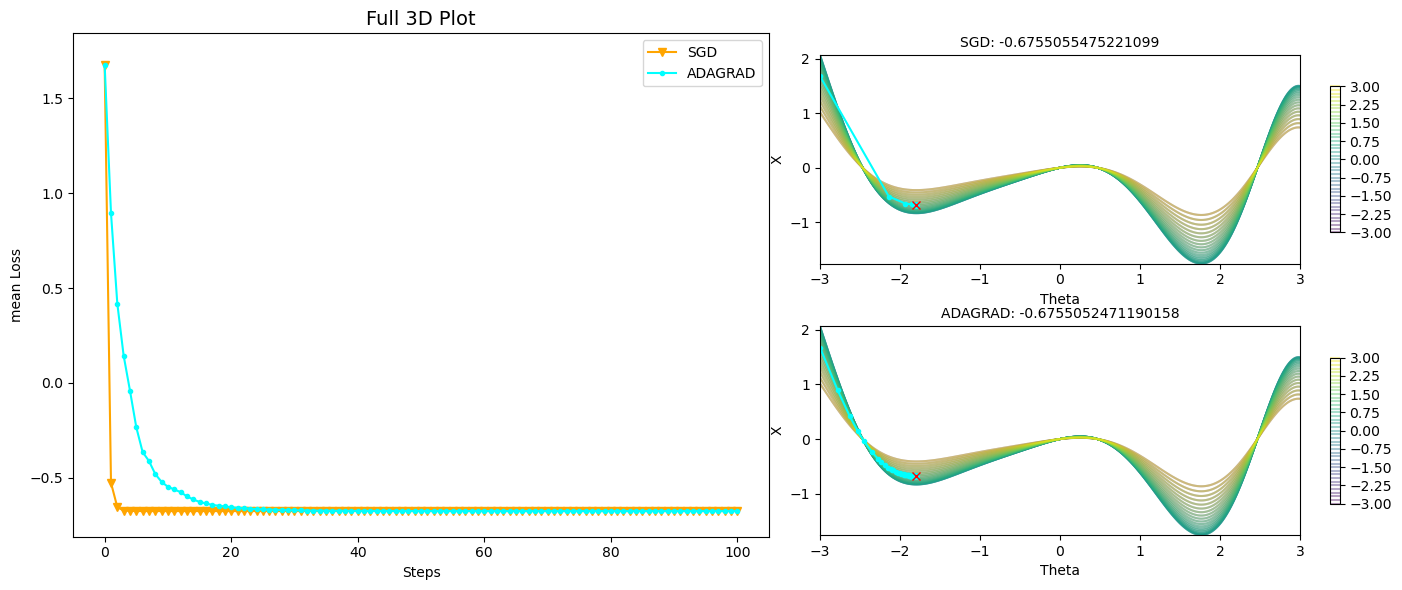

In [605]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create the main GridSpec for 1x2 layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

use_methods = ['SGD', 'ADAGRAD']
# First subplot: Full plot
ax_left = fig.add_subplot(gs[0])
max_y = 0
min_y = 0
for method in use_methods:
    values, start, end = pData[method]
    color = methods[method]['color']
    marker = methods[method]['marker']
    max_y = np.max([max_y, values[0][2]])
    min_y = np.min([min_y, np.min(list(zip(*values))[2])])
    print(f'{method}: {np.round(end - start,2)} Sec')
    
    ax_left.plot(*tuple(zip(*values))[-2:][::-1], color=color, marker = marker, label=method)
ax_left.set_title('Full 3D Plot', fontsize=14)
ax_left.set_xlabel('Steps')
ax_left.set_ylabel('mean Loss')
ax_left.set_ylim([min_y - 0.2 * np.abs(min_y), max_y*1.1])
ax_left.legend()

# Add colorbar to the left plot

# Second subplot: 3x1 layout within the right panel
gs_sub = GridSpec(len(use_methods), 1, figure=fig, left=0.55, right=0.95, top=0.9, bottom=0.1, hspace=0.3)
for i, method in enumerate(use_methods):
    ax = fig.add_subplot(gs_sub[i])
    cmap = plt.get_cmap('coolwarm')  # Set the colormap
    surf = ax.contour(THETA, Z,X, levels=50,cmap='viridis', alpha=0.4)
    ax.plot(*tuple(zip(*pData[method][0]))[:3][::2], color=color, marker = marker)
    ax.plot(*pData[method][0][-1][:3][::2], color='red', marker = 'x')
    ax.set_title(f'{method}: {np.min(tuple(zip(*pData[method][0]))[2])}', fontsize=10)

    ax.set_xlabel('Theta')
    ax.set_ylabel('X')

    # Add colorbar to each subplot
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Adadelta
```
위에서 Adagrad를 적용해봤지만 오히려 Learning Rate가 너무 느려진다..<br>
또 예상되는 문제점으로 Parameter별로 기울기의 Range가 다를텐데 <br>
범위가 큰 Parameter는 학습률이 매우 작아지고<br>
범위가 작은 Paramter는 학습률이 크게 유지될 것으로 보임. (불균형 문제)
```
그렇다면 학습률이 너무 급격히 작아지지 않도록
기존 $\sqrt{G^2+\epsilon}$에 **이동 평균**을 사용해 누적 범위를 제한하자!

Window사이즈 w의 이동 평균은 구현이 까다로우니 
**지수가중 이동 평균**을 사용한다. <br>

$E[g^2]_{t+1} = \gamma E[g^2]_{t} + (1-\gamma)E[g^2]_{t-1}$<br>
$기울기 제곱 이동 평균 G_{t,i} = \sqrt{E[g_{ii}^2]_t + \epsilon}$<br>

$ \theta_{t+1} = \theta_t + {\eta \over {\sqrt{E[g_{ii}^2]_t + \epsilon}}} \nabla_\theta J(\theta_t)$<br><br>
-->
$ \theta_{t+1} = \theta_t + {\eta \over {RMS[g]_t}} \nabla_\theta J(\theta_t)$<br>





SGD: 0.46 Sec
ADAGRAD: 0.4 Sec
ADADELTA_V1: 0.44 Sec


C:\Users\tardis\AppData\Local\Temp\ipykernel_4684\387705208.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


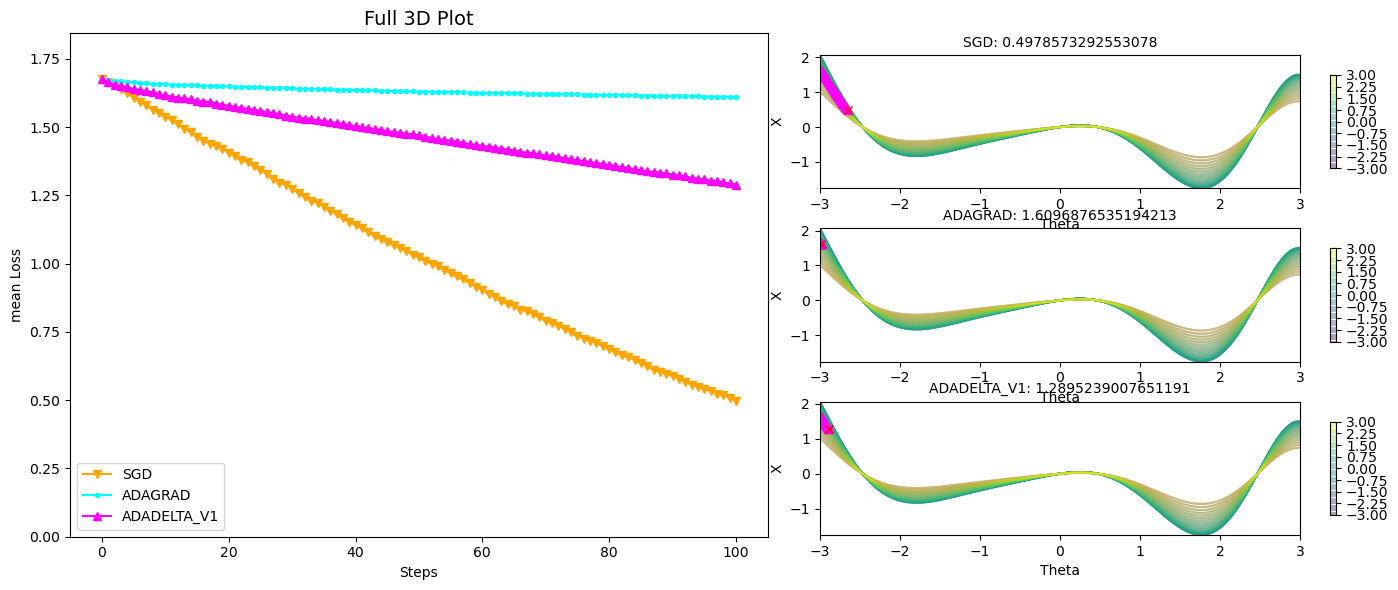

In [610]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create the main GridSpec for 1x2 layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

use_methods = ['SGD', 'ADAGRAD','ADADELTA_V1']
# First subplot: Full plot
ax_left = fig.add_subplot(gs[0])
max_y = 0
min_y = 0
for method in use_methods:
    values, start, end = pData[method]
    color = methods[method]['color']
    marker = methods[method]['marker']
    max_y = np.max([max_y, values[0][2]])
    min_y = np.min([min_y, np.min(list(zip(*values))[2])])
    print(f'{method}: {np.round(end - start,2)} Sec')
    
    ax_left.plot(*tuple(zip(*values))[-2:][::-1], color=color, marker = marker, label=method)
ax_left.set_title('Full 3D Plot', fontsize=14)
ax_left.set_xlabel('Steps')
ax_left.set_ylabel('mean Loss')
ax_left.set_ylim([min_y - 0.2 * np.abs(min_y), max_y*1.1])
ax_left.legend()

# Add colorbar to the left plot

# Second subplot: 3x1 layout within the right panel
gs_sub = GridSpec(len(use_methods), 1, figure=fig, left=0.55, right=0.95, top=0.9, bottom=0.1, hspace=0.3)
for i, method in enumerate(use_methods):
    ax = fig.add_subplot(gs_sub[i])
    cmap = plt.get_cmap('coolwarm')  # Set the colormap
    surf = ax.contour(THETA, Z,X, levels=50,cmap='viridis', alpha=0.4)
    ax.plot(*tuple(zip(*pData[method][0]))[:3][::2], color=color, marker = marker)
    ax.plot(*pData[method][0][-1][:3][::2], color='red', marker = 'x')
    ax.set_title(f'{method}: {np.min(tuple(zip(*pData[method][0]))[2])}', fontsize=10)

    ax.set_xlabel('Theta')
    ax.set_ylabel('X')

    # Add colorbar to each subplot
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

아직 불균형 문제는 해결되지 않은 것 같다. 


SGD: 0.41 Sec
ADAGRAD: 0.52 Sec
ADADELTA_V2: 0.49 Sec


C:\Users\tardis\AppData\Local\Temp\ipykernel_4684\3213561426.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


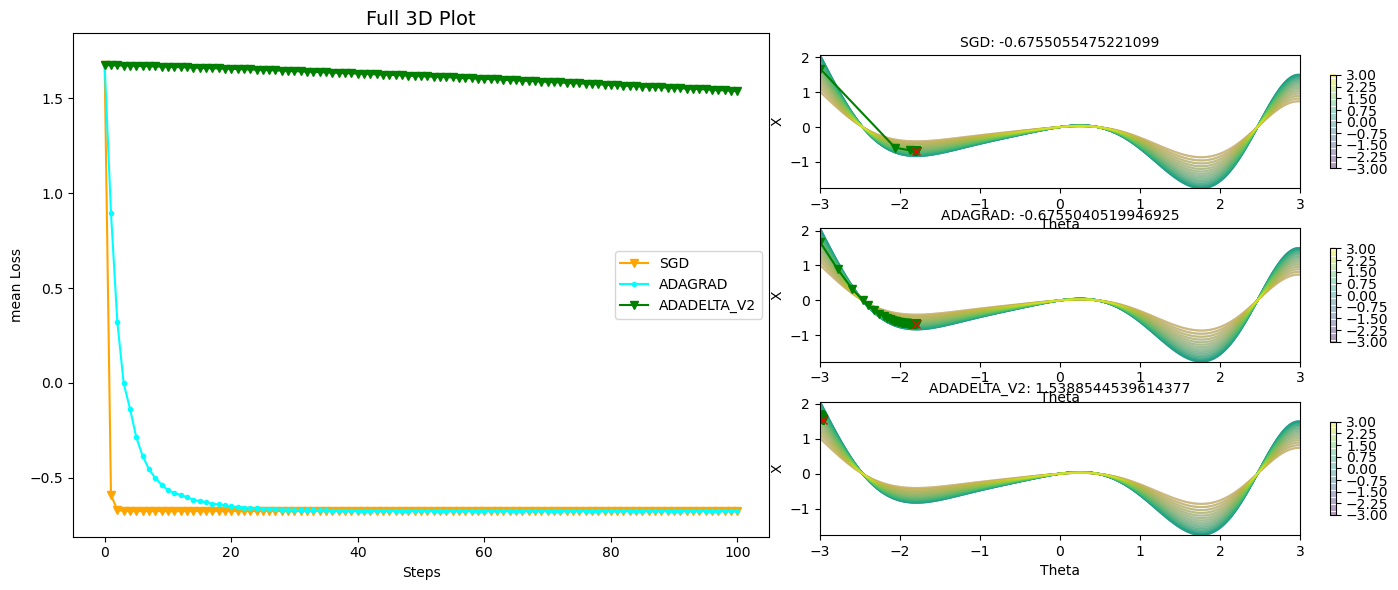

In [629]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create the main GridSpec for 1x2 layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

use_methods = ['SGD', 'ADAGRAD','ADADELTA_V2']
# First subplot: Full plot
ax_left = fig.add_subplot(gs[0])
max_y = 0
min_y = 0
for method in use_methods:
    values, start, end = pData[method]
    color = methods[method]['color']
    marker = methods[method]['marker']
    max_y = np.max([max_y, values[0][2]])
    min_y = np.min([min_y, np.min(list(zip(*values))[2])])
    print(f'{method}: {np.round(end - start,2)} Sec')
    
    ax_left.plot(*tuple(zip(*values))[-2:][::-1], color=color, marker = marker, label=method)
ax_left.set_title('Full 3D Plot', fontsize=14)
ax_left.set_xlabel('Steps')
ax_left.set_ylabel('mean Loss')
ax_left.set_ylim([min_y - 0.2 * np.abs(min_y), max_y*1.1])
ax_left.legend()

# Add colorbar to the left plot

# Second subplot: 3x1 layout within the right panel
gs_sub = GridSpec(len(use_methods), 1, figure=fig, left=0.55, right=0.95, top=0.9, bottom=0.1, hspace=0.3)
for i, method in enumerate(use_methods):
    ax = fig.add_subplot(gs_sub[i])
    cmap = plt.get_cmap('coolwarm')  # Set the colormap
    surf = ax.contour(THETA, Z,X, levels=50,cmap='viridis', alpha=0.4)
    ax.plot(*tuple(zip(*pData[method][0]))[:3][::2], color=color, marker = marker)
    ax.plot(*pData[method][0][-1][:3][::2], color='red', marker = 'x')
    ax.set_title(f'{method}: {np.min(tuple(zip(*pData[method][0]))[2])}', fontsize=10)

    ax.set_xlabel('Theta')
    ax.set_ylabel('X')

    # Add colorbar to each subplot
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

AdaDelta 구현은 맞는 것 같은데 뭔가 이상하다....

## RMSProp
AdaGrad의 단점을 보완하기위해 고안된 방법. AdaDelta와 비슷하고
AdaDelta의 중간 결과물..?

SGD: 0.35 Sec
ADAGRAD: 0.37 Sec
RMSProp: 0.45 Sec


C:\Users\tardis\AppData\Local\Temp\ipykernel_4684\940015195.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


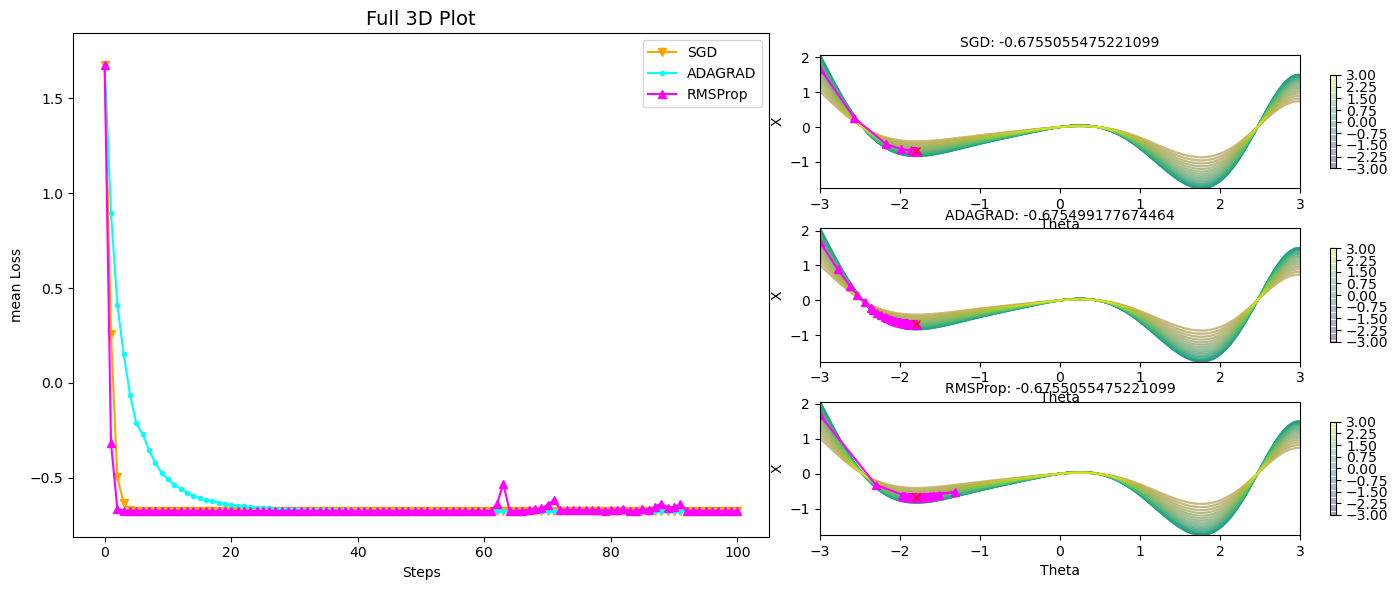

In [634]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create the main GridSpec for 1x2 layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

use_methods = ['SGD', 'ADAGRAD','RMSProp']
# First subplot: Full plot
ax_left = fig.add_subplot(gs[0])
max_y = 0
min_y = 0
for method in use_methods:
    values, start, end = pData[method]
    color = methods[method]['color']
    marker = methods[method]['marker']
    max_y = np.max([max_y, values[0][2]])
    min_y = np.min([min_y, np.min(list(zip(*values))[2])])
    print(f'{method}: {np.round(end - start,2)} Sec')
    
    ax_left.plot(*tuple(zip(*values))[-2:][::-1], color=color, marker = marker, label=method)
ax_left.set_title('Full 3D Plot', fontsize=14)
ax_left.set_xlabel('Steps')
ax_left.set_ylabel('mean Loss')
ax_left.set_ylim([min_y - 0.2 * np.abs(min_y), max_y*1.1])
ax_left.legend()

# Add colorbar to the left plot

# Second subplot: 3x1 layout within the right panel
gs_sub = GridSpec(len(use_methods), 1, figure=fig, left=0.55, right=0.95, top=0.9, bottom=0.1, hspace=0.3)
for i, method in enumerate(use_methods):
    ax = fig.add_subplot(gs_sub[i])
    cmap = plt.get_cmap('coolwarm')  # Set the colormap
    surf = ax.contour(THETA, Z,X, levels=50,cmap='viridis', alpha=0.4)
    ax.plot(*tuple(zip(*pData[method][0]))[:3][::2], color=color, marker = marker)
    ax.plot(*pData[method][0][-1][:3][::2], color='red', marker = 'x')
    ax.set_title(f'{method}: {np.min(tuple(zip(*pData[method][0]))[2])}', fontsize=10)

    ax.set_xlabel('Theta')
    ax.set_ylabel('X')

    # Add colorbar to each subplot
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

# ADAM
RMSProp + Momentum

SGD: 0.43 Sec
ADAGRAD: 0.52 Sec
RMSProp: 0.45 Sec
ADAM: 0.36 Sec
NAG: 0.41 Sec


C:\Users\tardis\AppData\Local\Temp\ipykernel_4684\405623755.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


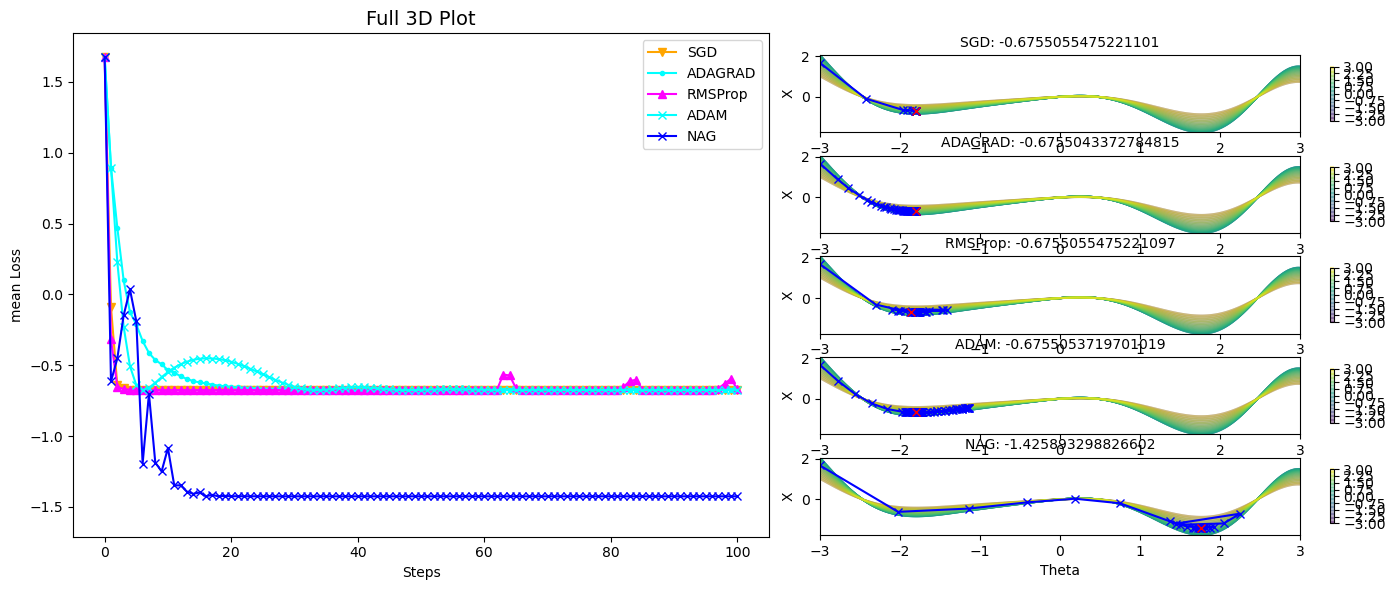

In [637]:
#ADAM
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create the main GridSpec for 1x2 layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

use_methods = ['SGD', 'ADAGRAD','RMSProp','ADAM','NAG']
# First subplot: Full plot
ax_left = fig.add_subplot(gs[0])
max_y = 0
min_y = 0
for method in use_methods:
    values, start, end = pData[method]
    color = methods[method]['color']
    marker = methods[method]['marker']
    max_y = np.max([max_y, values[0][2]])
    min_y = np.min([min_y, np.min(list(zip(*values))[2])])
    print(f'{method}: {np.round(end - start,2)} Sec')
    
    ax_left.plot(*tuple(zip(*values))[-2:][::-1], color=color, marker = marker, label=method)
ax_left.set_title('Full 3D Plot', fontsize=14)
ax_left.set_xlabel('Steps')
ax_left.set_ylabel('mean Loss')
ax_left.set_ylim([min_y - 0.2 * np.abs(min_y), max_y*1.1])
ax_left.legend()

# Add colorbar to the left plot

# Second subplot: 3x1 layout within the right panel
gs_sub = GridSpec(len(use_methods), 1, figure=fig, left=0.55, right=0.95, top=0.9, bottom=0.1, hspace=0.3)
for i, method in enumerate(use_methods):
    ax = fig.add_subplot(gs_sub[i])
    cmap = plt.get_cmap('coolwarm')  # Set the colormap
    surf = ax.contour(THETA, Z,X, levels=50,cmap='viridis', alpha=0.4)
    ax.plot(*tuple(zip(*pData[method][0]))[:3][::2], color=color, marker = marker)
    ax.plot(*pData[method][0][-1][:3][::2], color='red', marker = 'x')
    ax.set_title(f'{method}: {np.min(tuple(zip(*pData[method][0]))[2])}', fontsize=10)

    ax.set_xlabel('Theta')
    ax.set_ylabel('X')

    # Add colorbar to each subplot
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

ADAM: 0.34 Sec
ADAM2: 0.33 Sec
SGD: 0.41 Sec
NAG: 0.47 Sec


C:\Users\tardis\AppData\Local\Temp\ipykernel_4684\1419983741.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


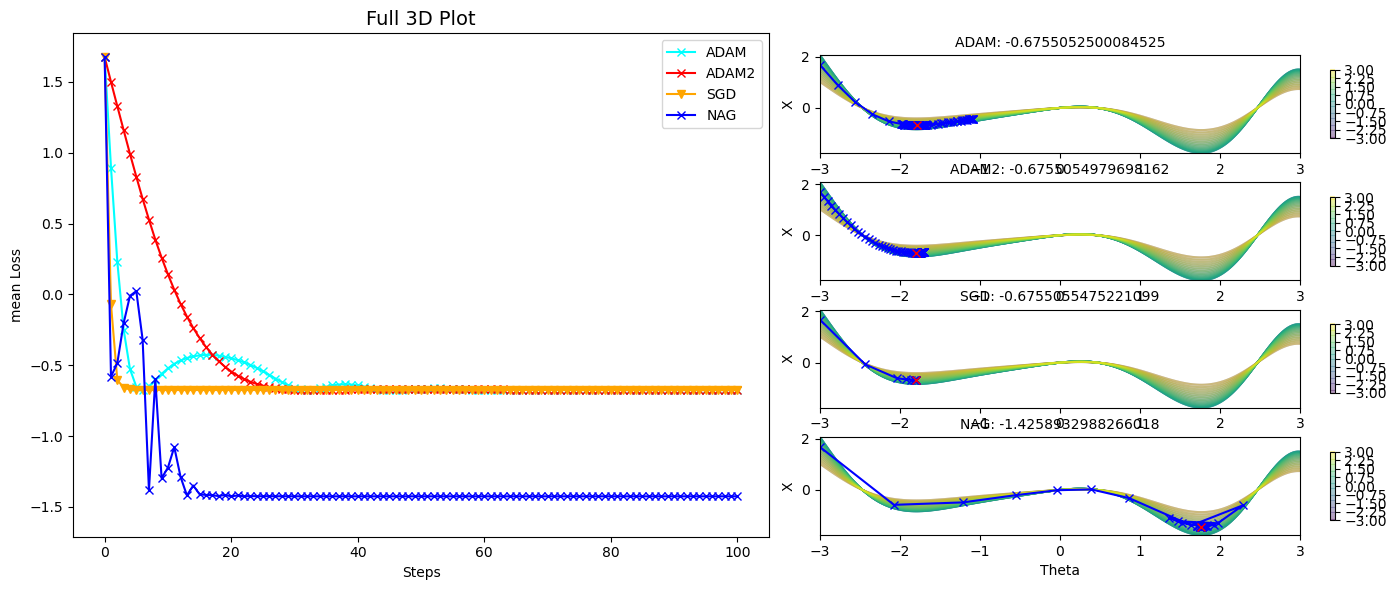

In [642]:

#ADAM
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create the main GridSpec for 1x2 layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

use_methods = ['ADAM','ADAM2', 'SGD','NAG']
# First subplot: Full plot
ax_left = fig.add_subplot(gs[0])
max_y = 0
min_y = 0
for method in use_methods:
    values, start, end = pData[method]
    color = methods[method]['color']
    marker = methods[method]['marker']
    max_y = np.max([max_y, values[0][2]])
    min_y = np.min([min_y, np.min(list(zip(*values))[2])])
    print(f'{method}: {np.round(end - start,2)} Sec')
    
    ax_left.plot(*tuple(zip(*values))[-2:][::-1], color=color, marker = marker, label=method)
ax_left.set_title('Full 3D Plot', fontsize=14)
ax_left.set_xlabel('Steps')
ax_left.set_ylabel('mean Loss')
ax_left.set_ylim([min_y - 0.2 * np.abs(min_y), max_y*1.1])
ax_left.legend()

# Add colorbar to the left plot

# Second subplot: 3x1 layout within the right panel
gs_sub = GridSpec(len(use_methods), 1, figure=fig, left=0.55, right=0.95, top=0.9, bottom=0.1, hspace=0.3)
for i, method in enumerate(use_methods):
    ax = fig.add_subplot(gs_sub[i])
    cmap = plt.get_cmap('coolwarm')  # Set the colormap
    surf = ax.contour(THETA, Z,X, levels=50,cmap='viridis', alpha=0.4)
    ax.plot(*tuple(zip(*pData[method][0]))[:3][::2], color=color, marker = marker)
    ax.plot(*pData[method][0][-1][:3][::2], color='red', marker = 'x')
    ax.set_title(f'{method}: {np.min(tuple(zip(*pData[method][0]))[2])}', fontsize=10)

    ax.set_xlabel('Theta')
    ax.set_ylabel('X')

    # Add colorbar to each subplot
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

<img src="./optimizer.png"><br>
<img src="https://img1.daumcdn.net/thumb/R720x0.q80/?scode=mtistory2&fname=http%3A%2F%2Fcfile23.uf.tistory.com%2Fimage%2F996A04425AB85ED0260F3E"><br>
<img src="https://img1.daumcdn.net/thumb/R720x0.q80/?scode=mtistory2&fname=http%3A%2F%2Fcfile28.uf.tistory.com%2Fimage%2F99EF38455AB85F5B227DAE"><br>
<img src="https://i.imgur.com/pD0hWu5.gif?1"><br>


